# Week 1 — Session 3
## Sampling, Law of Large Numbers, and Central Limit Theorem

### Goals
- Understand Population and Sample
- Compare sampling strategies
- Observe Sampling Error
- Understand the Law of Large Numbers
- Simulate the Central Limit Theorem
- Distinguish large sample size from representativeness
- Apply sampling logic to Tehran urban analysis

In [2]:
import numpy as np
import pandas as pd

## Synthetic Population

We create a hypothetical population of 1,000 observations.

The variable `access_time` represents walking time to public transport.

In [3]:
np.random.seed(42)

population = pd.DataFrame({
    "access_time": np.random.exponential(
        scale=12,
        size=1000
    )
})

population.head()

,access_time
0,5.631217
1,36.121457
2,15.800948
3,10.955311
4,2.035498


In [4]:
population_mean = population["access_time"].mean()

print(
    "Population Mean:",
    population_mean
)

Population Mean: 11.670071375582692


## Sampling Error

Different samples from the same population produce different sample means.

Sampling Error is the natural difference between a sample statistic and the population parameter.

In [5]:
sample_20 = population["access_time"].sample(
    n=20,
    random_state=1
)

sample_mean_20 = sample_20.mean()

print("Population Mean:", population_mean)
print("Sample Mean:", sample_mean_20)
print(
    "Sampling Error:",
    abs(sample_mean_20 - population_mean)
)

Population Mean: 11.670071375582692
Sample Mean: 14.073981171509667
Sampling Error: 2.4039097959269746


In [6]:
sample_100 = population["access_time"].sample(
    n=100,
    random_state=1
)

sample_500 = population["access_time"].sample(
    n=500,
    random_state=1
)

print("Population Mean:", population_mean)

print(
    "n = 20:",
    sample_20.mean()
)

print(
    "n = 100:",
    sample_100.mean()
)

print(
    "n = 500:",
    sample_500.mean()
)

Population Mean: 11.670071375582692
n = 20: 14.073981171509667
n = 100: 11.541255067714529
n = 500: 11.833784132912198


### Interpretation

Larger samples often produce estimates closer to the population value.

However, the improvement is not guaranteed to be monotonic for every single sample.

The Law of Large Numbers describes general behavior as sample size increases.

## Law of Large Numbers

As the number of independent observations increases, the sample mean tends to get closer to the population mean.

In [7]:
sample_sizes = [
    5,
    10,
    20,
    50,
    100,
    200,
    500
]

results = []

for n in sample_sizes:
    sample = population["access_time"].sample(
        n=n,
        random_state=n
    )

    results.append({
        "sample_size": n,
        "sample_mean": sample.mean(),
        "error": abs(
            sample.mean()
            - population_mean
        )
    })

lln_results = pd.DataFrame(results)

lln_results

,sample_size,sample_mean,error
0,5,17.002171,5.332100
1,10,16.891865,5.221794
2,20,13.963840,2.293769
3,50,15.464575,3.794504
4,100,12.317265,0.647194
5,200,13.154052,1.483981
6,500,11.605097,0.064974


### Important

Large Sample does not automatically mean:

- unbiased sample
- representative sample
- correct sampling method

Sample Size and Sampling Quality are different concepts.

# Sampling Bias

A very large biased sample can still produce a misleading estimate.

In [8]:
biased_population = pd.DataFrame({
    "zone": (
        ["Near Metro"] * 500
        + ["Far From Metro"] * 500
    ),
    "access_time": np.concatenate([
        np.random.normal(
            loc=5,
            scale=1,
            size=500
        ),
        np.random.normal(
            loc=20,
            scale=3,
            size=500
        )
    ])
})

biased_population.groupby(
    "zone"
)["access_time"].mean()

zone
Far From Metro    20.242834
Near Metro         5.116847
Name: access_time, dtype: float64

In [9]:
true_mean = biased_population[
    "access_time"
].mean()

biased_sample = biased_population[
    biased_population["zone"] == "Near Metro"
]["access_time"].sample(
    n=400,
    random_state=42
)

print("True Population Mean:", true_mean)

print(
    "Large Biased Sample Mean:",
    biased_sample.mean()
)

True Population Mean: 12.679840633872594
Large Biased Sample Mean: 5.120421878009461


### Interpretation

The sample contains 400 observations, which is large.

But it systematically excludes people living far from metro stations.

Therefore:

Large Sample ≠ Representative Sample

## Stratified Sampling

When the population contains important subgroups, we can sample from each subgroup.

Example:

- North
- Center
- South

In [10]:
tehran_population = pd.DataFrame({
    "zone": (
        ["North"] * 150
        + ["Center"] * 350
        + ["South"] * 500
    )
})

tehran_population["zone"].value_counts(
    normalize=True
)

zone
South     0.50
Center    0.35
North     0.15
Name: proportion, dtype: float64

Population proportions:

- North = 15%
- Center = 35%
- South = 50%

For a sample of 1,000 observations, proportional stratified sampling would preserve these proportions.

In [11]:
sample_size = 1000

north_n = int(
    sample_size * 0.15
)

center_n = int(
    sample_size * 0.35
)

south_n = int(
    sample_size * 0.50
)

print("North:", north_n)
print("Center:", center_n)
print("South:", south_n)

North: 150
Center: 350
South: 500


# Central Limit Theorem

CLT does NOT say that raw data becomes normal.

It says that the sampling distribution of sample means tends toward an approximately normal distribution under suitable conditions.

In [12]:
sample_means = []

for i in range(1000):

    sample = population[
        "access_time"
    ].sample(
        n=30,
        replace=True
    )

    sample_means.append(
        sample.mean()
    )

sample_means = pd.Series(
    sample_means
)

sample_means.describe()

count    1000.000000
mean       11.658876
std         2.106670
min         5.494484
25%        10.201549
50%        11.550340
75%        12.863022
max        19.741267
dtype: float64

<Axes: >

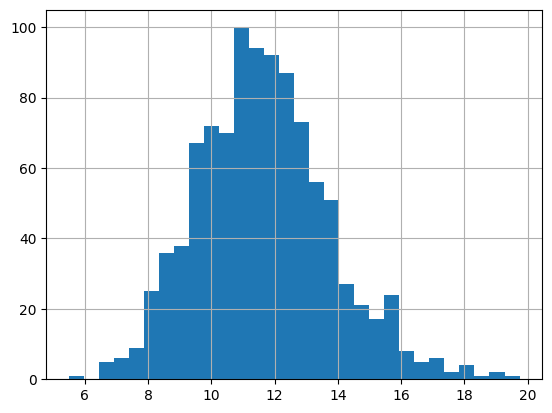

In [13]:
sample_means.hist(
    bins=30
)

### Interpretation

The original population was generated using an exponential distribution.

It is not normally distributed.

However, the distribution of repeated sample means becomes much more symmetric and approximately normal.

This is the key idea behind the Central Limit Theorem.

<Axes: >

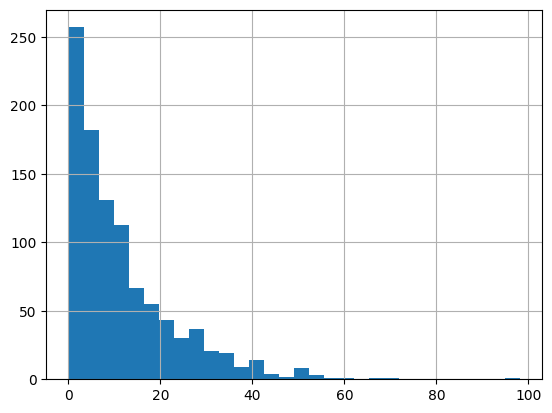

In [14]:
population[
    "access_time"
].hist(
    bins=30
)

Compare:

1. Distribution of raw observations
2. Distribution of repeated sample means

They are not the same object.

CLT applies to the second one.

# Tehran Project Connection

Possible future sampling hierarchy:

Tehran
→ Municipal District
→ Urban Stratum
→ Neighborhood
→ Public Space / Street / Parcel
→ Observation

Before using a sample, define:

- Population
- Sampling Unit
- Sampling Strategy
- Potential Bias
- Representativeness
- Limits of Generalization

## Tehran Sampling Plan — V0.1

### Research Question
How can urban indicators be sampled reliably when complete data is not available?

### Possible Strata
- Geography
- Population Density
- Land Use
- Public Transport Accessibility
- Green Space
- Urban Morphology

### Main Risk
Convenience Sampling

Choosing only easy-to-access or familiar neighborhoods can systematically distort conclusions.

# Independent Exercise

Design a sampling strategy for studying public-space satisfaction in Tehran.

Specify:

1. Population
2. Unit of Observation
3. Sampling Method
4. Why this method is suitable
5. Possible Sampling Bias
6. How to improve Representativeness
7. What conclusions should NOT be generalized

# Session Summary

Key concepts:

- Population and Sample are different.
- Sampling Error is natural.
- Sampling Bias is systematic.
- Larger samples usually reduce Sampling Error.
- Larger samples do not automatically remove Bias.
- Stratified Sampling can improve representativeness in heterogeneous populations.
- LLN explains convergence of sample statistics.
- CLT concerns the distribution of sample means, not raw data.